Compare end-to-end compile time versus expected sentence depth across 3 compilers:

BQskit is a really bad comparison. It's not designed to get arbitrary gates, so they have a limited library of input gates. Thus, we have to use custom definitions of 4th root gates that potenitally are breaking the jax caching? More, this doesn't allow any way to define costs - it is only concerned with gate count. BAD! There might be a more optimized way to do this, but would require modifying the code more than we already have. There is PowerGate but only for integers, so how do I make small fractional gates? There is also Parameterized Gates but doesn't quite help because there is no way to use it to fix parameters.

Nuop is a better comparison, except for the one-shot parameter optimization.  

In [ ]:
from time import perf_counter
from tqdm import tqdm
import numpy as np
from qiskit.quantum_info import average_gate_fidelity, random_unitary, Operator
import numpy as np
from gulps.comparisons.nuop_driver import (
    ParallelGateReplacementPass,
    cnot_gate,
    fsim_gate,
    cphase_gate,
    xy_gate,
    get_gate_unitary_qiskit,
)
from bqskit.ir.gates import U3Gate
from bqskit import MachineModel
from bqskit.ext import qiskit_to_bqskit
from bqskit import compile
from bqskit.qis import UnitaryMatrix
from bqskit.ir import gates
from gulps.synthesis.gulps_decomposer import GulpsDecomposer
from qiskit.circuit.library import iSwapGate, CXGate, SwapGate
from qiskit import QuantumCircuit
from gulps.core.coverage import expected_costs
from qiskit.converters import circuit_to_dag
from bqskit.ext.qiskit import bqskit_to_qiskit

In [9]:
from bqskit._logging import disable_logging
from gulps import logger

logger.setLevel("INFO")
disable_logging()

In [ ]:
from gulps.comparisons.bqskit_driver import Sqrt4iSwapGate
from qiskit.circuit.library import XXPlusYYGate
from bqskit.ir.gates import Sqrt4CXGate


def fsim(theta, phi):
    qc = QuantumCircuit(2, name="fsim")
    qc.append(XXPlusYYGate(2 * theta), [0, 1])
    qc.cp(phi, 0, 1)
    return qc.to_gate()

Note, in order for bqskit to work properly I have to modify the package itself. Defining a new class of gates breaks the jax/differentiable unitary stuff. Therefore, instead of creating custom definitions and importing them, I add in new classes to bqskit.ir.gates.constant because my guess is that including them in __init__ is where the differentiating things happen.

In [11]:
isa_library = {
    "cx": [
        [(CXGate().power(1.0), 1.0, "cx")],  # Used in GULPS
        {
            "gate_defs": [cphase_gate],
            "gate_params": [[np.pi]],
            "gate_labels": ["cx"],
            "fidelity_dict_2q_gate": {(0, 1): [1.0]},
            "fidelity_list_1q_gate": [1.0 for _ in range(54)],
            "tol": 0.0,
        },  # NuOp
        {gates.CNOTGate(), U3Gate()},  # BQSKit
    ],
    "sqrtcx": [
        [(CXGate().power(1 / 2), 1.0, "sqrtcx")],  # Used in GULPS
        {
            "gate_defs": [cphase_gate],
            "gate_params": [[np.pi / 2]],
            "gate_labels": ["sqcx"],
            "fidelity_dict_2q_gate": {(0, 1): [1.0]},
            "fidelity_list_1q_gate": [1.0 for _ in range(54)],
            "tol": 0.0,
        },  # NuOp
        {gates.SqrtCNOTGate(), U3Gate()},  # BQSKit
    ],
    "sqrt3cx": [
        [(CXGate().power(1 / 3), 1.0, "sqrt3cx")],
        {
            "gate_defs": [cphase_gate],
            "gate_params": [[np.pi / 3]],
            "gate_labels": ["sqrt3cx"],
            "fidelity_dict_2q_gate": {(0, 1): [1.0]},
            "fidelity_list_1q_gate": [1.0 for _ in range(54)],
            "tol": 0.0,
        },
        {gates.Sqrt3CXGate(), U3Gate()},  # BQSKit not defined
    ],
    "sqrt4cx": [
        [(CXGate().power(1 / 4), 1.0, "sqrt4cx")],  # Used in GULPS
        {
            "gate_defs": [cphase_gate],
            "gate_params": [[np.pi / 4]],
            "gate_labels": ["sq4cx"],
            "fidelity_dict_2q_gate": {(0, 1): [1.0]},
            "fidelity_list_1q_gate": [1.0 for _ in range(54)],
            "tol": 0.0,
        },  # NuOp
        {gates.Sqrt4CXGate(), U3Gate()},  # BQSKit
        # None,  # BQSKit not defined
    ],
    "sqrt5cx": [
        [(CXGate().power(1 / 5), 1.0, "sqrt5cx")],
        {
            "gate_defs": [cphase_gate],
            "gate_params": [[np.pi / 5]],
            "gate_labels": ["sqrt5cx"],
            "fidelity_dict_2q_gate": {(0, 1): [1.0]},
            "fidelity_list_1q_gate": [1.0 for _ in range(54)],
            "tol": 0.0,
        },
        {gates.Sqrt5CXGate(), U3Gate()},  # BQSKit not defined
    ],
    "sqrt6cx": [
        [(CXGate().power(1 / 6), 1.0, "sqrt6cx")],
        {
            "gate_defs": [cphase_gate],
            "gate_params": [[np.pi / 6]],
            "gate_labels": ["sqrt6cx"],
            "fidelity_dict_2q_gate": {(0, 1): [1.0]},
            "fidelity_list_1q_gate": [1.0 for _ in range(54)],
            "tol": 0.0,
        },
        {gates.Sqrt6CXGate(), U3Gate()},  # BQSKit not defined
    ],
}

NOTE, remember that nuop max_depth is hardcoded in gulps.utils!

In [12]:
results = []
fid_results = {"gulps": [], "nuop": [], "bqskit": []}
expected_depths = []
nuop_cost_ratio = []
bqskit_cost_ratio = []

for isa_name, (gulps_isa, nuop_params, bqskit_gateset) in isa_library.items():
    print(f"Running benchmark for ISA: {isa_name}")

    # Init decomposers
    gate_set, costs, names = zip(*gulps_isa)
    gulps_decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)
    nuop_decomposer = ParallelGateReplacementPass(**nuop_params)
    bqskit_model = MachineModel(2, gate_set=bqskit_gateset)
    nuop_cost_list = []
    bqskit_cost_list = []
    expected_depth = expected_costs(gulps_decomposer.isa.coverage_set)[1]
    expected_depths.append(expected_depth)
    fid_results["gulps"].append([])
    fid_results["nuop"].append([])
    fid_results["bqskit"].append([])

    for idx in tqdm(range(8), leave=False):
        u_target = random_unitary(4, seed=idx)

        # GULPS
        try:
            t0 = perf_counter()
            qc = gulps_decomposer(u_target)
            t1 = perf_counter()
            results.append(("gulps", isa_name, expected_depth, t1 - t0))
            fid = average_gate_fidelity(u_target, Operator(qc))
            fid_results["gulps"][-1].append(fid)
        except:
            continue
            raise Exception(f"GULPS failed for {isa_name} with input {u_target}")

        # NuOp
        try:
            t0 = perf_counter()
            nuop_input = QuantumCircuit(2)
            nuop_input.append(u_target, [0, 1])
            nuop_output = nuop_decomposer.run(nuop_input, exact_decom=True)
            nuop_cost_list.append(len(circuit_to_dag(nuop_output).two_qubit_ops()))
            t1 = perf_counter()
            results.append(("nuop", isa_name, expected_depth, t1 - t0))
            fid = average_gate_fidelity(u_target, Operator(nuop_output))
            fid_results["nuop"][-1].append(fid)
        except:
            raise Exception(f"NuOp failed for {isa_name} with input {u_target}")

        # BQSKit
        if bqskit_gateset:  # Skip if None or empty
            try:
                t0 = perf_counter()
                bqskit_output = compile(
                    UnitaryMatrix(u_target.to_matrix()), model=bqskit_model
                )
                bqskit_cost_list.append(
                    sum(bqskit_output.gate_counts.values())
                    - bqskit_output.gate_counts[U3Gate()]
                )

                t1 = perf_counter()
                results.append(("bqskit", isa_name, expected_depth, t1 - t0))
                fid = average_gate_fidelity(
                    u_target, Operator(bqskit_output.get_unitary()._utry)
                )

                fid_results["bqskit"][-1].append(fid)
            except:
                raise Exception(f"BQSKit failed for {isa_name} with input {u_target}")

    nuop_cost_ratio.append(np.mean(nuop_cost_list) / expected_depth)
    if bqskit_gateset:
        bqskit_cost_ratio.append(np.mean(bqskit_cost_list) / expected_depth)
    else:
        bqskit_cost_ratio.append(None)

Running benchmark for ISA: cx


Running benchmark for ISA: sqrtcx


Running benchmark for ISA: sqrt3cx


Running benchmark for ISA: sqrt4cx


Running benchmark for ISA: sqrt5cx


Running benchmark for ISA: sqrt6cx


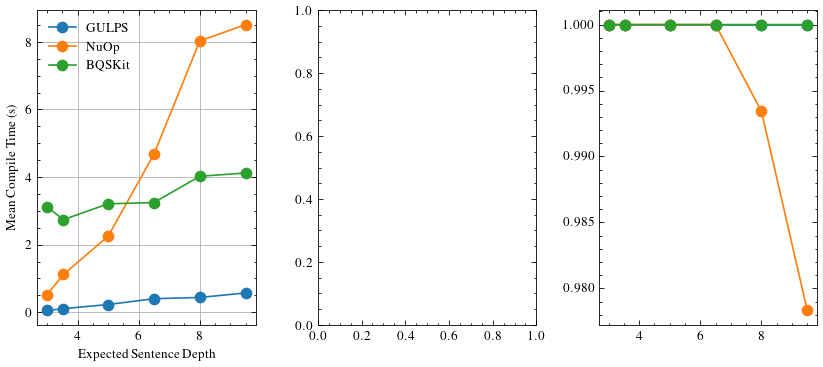

In [14]:
import scienceplots
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

compiler_labels = {"gulps": "GULPS", "nuop": "NuOp", "bqskit": "BQSKit"}
colors = {"gulps": "tab:blue", "nuop": "tab:orange", "bqskit": "tab:green"}

# Organize: compiler → depth → list of durations
timing_data = defaultdict(lambda: defaultdict(list))
for compiler, isa_name, expected_depth, compile_time in results:
    timing_data[compiler][expected_depth].append(compile_time)

# Extract one expected depth per ISA (GULPS value is always used)
isa_names = list(isa_library.keys())
# Plot style
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, (ax_time, ax_cost, ax_fid) = plt.subplots(1, 3, figsize=(7, 3.2), dpi=120)

    # === Left: Compile Time vs Expected Depth ===
    for compiler in ["gulps", "nuop", "bqskit"]:
        if compiler not in timing_data:
            continue
        depths = sorted(timing_data[compiler])
        means = [np.mean(timing_data[compiler][d]) for d in depths]
        ax_time.plot(
            depths, means, "o-", label=compiler_labels[compiler], color=colors[compiler]
        )

    ax_time.set_xlabel("Expected Sentence Depth")
    ax_time.set_ylabel("Mean Compile Time (s)")
    ax_time.legend()
    ax_time.grid(True)
    # ax_time.set_yscale("log")

    # # === Right: Cost Ratio vs Expected Depth ===
    # ax_cost.scatter(
    #     expected_depths,
    #     nuop_cost_ratio,
    #     color=colors["nuop"],
    #     label="NuOp",
    #     marker="o",
    # )
    # ax_cost.scatter(
    #     expected_depths,
    #     [r if r is not None else np.nan for r in bqskit_cost_ratio],
    #     color=colors["bqskit"],
    #     label="BQSKit",
    #     marker="s",
    #     facecolors="none",
    #     linewidths=1.0,
    # )

    # ax_cost.set_xlabel("Expected Sentence Depth")
    # ax_cost.set_ylabel("Mean Depth / GULPS Depth")
    # ax_cost.grid(True)
    # ax_cost.legend()

    # plot fid_results on ax_fid
    # fid_results is a dictionary containing name:[[], []] nested list
    for compiler in ["gulps", "nuop", "bqskit"]:
        if compiler not in fid_results:
            continue
        depths = expected_depths
        means = [np.mean(fid_results[compiler][d]) for d in range(len(depths))]
        ax_fid.plot(
            depths, means, "o-", label=compiler_labels[compiler], color=colors[compiler]
        )

    fig.tight_layout()
    plt.show()